# Jour 2 · Construire une première prévision et la mesurer

## Objectifs

- expliquer ce qu'une prévision cherche réellement à produire ;
- construire des baselines de persistance et saisonnière ;
- séparer passé et futur sans fuite de données ;
- calculer et interpréter MAE et RMSE ;
- décider si un modèle plus complexe mérite d'être essayé.

## Du Jour 1 au Jour 2

Hier, nous avons rendu les mesures fiables, observé leurs motifs et réservé une période de test située dans le futur. Aujourd'hui, nous changeons de question :

> À partir du passé connu, quelle valeur attendons-nous pour un instant futur ?

Dans notre installation HVAC, prévoir la puissance électrique peut aider à anticiper une pointe de consommation. Plus tard, l'écart entre la valeur attendue et la valeur réellement mesurée deviendra aussi un signal d'anomalie.

Une prévision n'est pas une certitude. C'est une estimation que l'on doit confronter à des observations réellement arrivées **après** l'entraînement.

![Ingénieur observant l'historique des capteurs HVAC et sa prolongation sous forme de prévision](../assets/jour_02/00_prevision_hvac.png)

*Le forecasting utilise le passé connu pour estimer une zone future encore inconnue. Lorsque ce futur arrive, nous pouvons mesurer l'écart entre prévision et réalité.*

## Le vocabulaire minimum

| Terme | Sens simple | Dans ce notebook |
|---|---|---|
| **Cible** | variable que l'on veut prévoir | puissance électrique en kW |
| **Entraînement** | passé autorisé pour construire la méthode | toutes les heures sauf les sept derniers jours |
| **Test** | futur caché pendant la construction | les sept derniers jours |
| **Horizon** | distance ou période à prévoir | 168 heures |
| **Prévision** | valeur estimée avant de voir la réalité | puissance attendue |
| **Erreur** | différence entre réalité et prévision | erreur en kW |
| **Baseline** | règle simple servant de référence | dernière valeur ou semaine précédente |

Le jeu de test ne sert pas à ajuster la méthode. Il simule ce qui se passerait après sa mise en production.

## Pourquoi commencer par une baseline ?

Une baseline répond à une question très concrète : **notre modèle fait-il mieux qu'une règle évidente ?**

Imaginons un modèle sophistiqué qui demande dix minutes de calcul et beaucoup de maintenance. S'il prévoit moins bien que « reprendre la valeur de la semaine dernière », sa complexité n'apporte rien. La baseline sert donc :

- de point de comparaison ;
- de test de cohérence du protocole ;
- de solution de secours compréhensible ;
- de rappel qu'un modèle doit produire une valeur métier mesurable.

Nous allons comparer deux règles simples :

1. **Persistance** : demain ressemble à la dernière valeur connue.
2. **Saisonnier naïf** : cette heure ressemble à la même heure de la semaine précédente.

![Comparaison visuelle entre une baseline de persistance et une baseline saisonnière](../assets/jour_02/01_baseline_persistance_saisonniere.png)

*La persistance prolonge un niveau. La baseline saisonnière répète un motif. Le bon repère dépend du comportement physique du signal.*

## Étape 1 — préparer une série horaire

Nous utilisons le fichier déjà nettoyé afin de nous concentrer sur la prévision. La puissance est mesurée toutes les quinze minutes ; **resample("1h").mean()** rassemble quatre mesures dans une moyenne horaire.

Avant tout calcul, vérifions la période, la fréquence et les ordres de grandeur. Une métrique n'a de sens que si l'unité de la cible est claire.

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error


def find_project_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "datasets").is_dir():
            return candidate
    raise FileNotFoundError("Dossier datasets introuvable. Lancez Jupyter depuis le projet.")


ROOT = find_project_root()
DATA_DIR = ROOT / "datasets"

plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv(DATA_DIR / "prepared" / "iot_hvac_clean.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

hourly = (
    df.set_index("timestamp")["power_kw"]
    .resample("1h")
    .mean()
    .rename("power_kw")
)

print("Période :", hourly.index.min(), "→", hourly.index.max())
print("Nombre d'heures :", len(hourly))
print(hourly.describe().round(2))

Période : 2026-07-01 00:00:00+00:00 → 2026-08-11 23:00:00+00:00
Nombre d'heures : 1008
count    1008.00
mean        2.37
std         1.46
min         1.05
25%         1.24
50%         1.33
75%         4.05
max         8.92
Name: power_kw, dtype: float64


### Comment lire cette sortie ?

- La période doit couvrir six semaines complètes.
- Le nombre d'observations doit correspondre à une série horaire régulière.
- **mean**, **min** et **max** donnent l'échelle habituelle de la puissance.
- Une future MAE de 0,2 devra donc être lue comme **0,2 kW**, et non comme « un score abstrait de 0,2 ».

Si la série contenait encore des trous, il faudrait les traiter avant de construire les baselines.

## Étape 2 — réserver un vrai futur

Nous choisissons les sept derniers jours comme test :

~~~text
passé disponible                                      futur simulé
|-------------------------- entraînement ----------------|---- test ----|
                                                        frontière
~~~

Sept jours représentent **7 × 24 = 168** valeurs horaires. Ce choix contient un cycle hebdomadaire complet et permet une comparaison avec la semaine précédente. Il ne s'agit pas d'une règle universelle : l'horizon doit représenter l'usage réel.

La frontière appartient ici à l'entraînement ; toutes les dates strictement suivantes appartiennent au test.

In [2]:
test_duration = pd.Timedelta(days=7)
cutoff = hourly.index.max() - test_duration

train = hourly.loc[hourly.index <= cutoff]
test = hourly.loc[hourly.index > cutoff]

assert train.index.max() < test.index.min()
assert len(test) == 7 * 24

print(len(train), "heures d'entraînement")
print(len(test), "heures de test")
print("Dernière heure connue :", train.index.max())
print("Première heure à prévoir :", test.index.min())

840 heures d'entraînement
168 heures de test
Dernière heure connue : 2026-08-04 23:00:00+00:00
Première heure à prévoir : 2026-08-05 00:00:00+00:00


C:\Users\bstorm_user\AppData\Local\Temp\ipykernel_74988\2917741129.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  test_duration = pd.Timedelta(days=7)


## Étape 3 — baseline de persistance

La persistance recopie la dernière valeur connue pour chaque heure future. Si la dernière puissance observée est de 3,1 kW, toutes les prévisions valent 3,1 kW.

Cette règle est crédible pour un horizon très court ou un signal qui évolue lentement. Elle devient faible lorsqu'un cycle journalier important continue pendant la période de test.

La série de prévision reçoit exactement le même index que le test. Cet alignement est essentiel : chaque prévision doit être comparée à la réalité du **même timestamp**.

In [3]:
persistence = pd.Series(
    train.iloc[-1],
    index=test.index,
    name="persistance",
)

pd.DataFrame({
    "réel": test.head(4),
    "persistance": persistence.head(4),
})

,réel,persistance
timestamp,,
2026-08-05 00:00:00+00:00,1.2960,1.254
2026-08-05 01:00:00+00:00,1.3050,1.254
2026-08-05 02:00:00+00:00,1.2525,1.254
2026-08-05 03:00:00+00:00,1.2080,1.254


## Étape 4 — baseline saisonnière hebdomadaire

L'exploration du Jour 1 a montré des rythmes liés à l'heure et au jour. Une règle plus pertinente consiste donc à répéter les 168 dernières heures d'entraînement :

~~~text
lundi 09 h de la semaine passée  →  lundi 09 h à prévoir
mardi 14 h de la semaine passée  →  mardi 14 h à prévoir
~~~

Cette méthode suppose que le motif hebdomadaire reste assez stable. Elle échouera en cas de changement d'horaire, de météo exceptionnelle, d'arrêt de production ou de dérive de l'équipement.

La fonction **np.resize** répète le motif si le test est plus long que 168 heures. Ici les deux longueurs sont identiques, mais nous vérifions tout de même l'alignement.

In [4]:
weekly_period = 24 * 7
last_week_pattern = train.iloc[-weekly_period:].to_numpy()
seasonal_values = np.resize(last_week_pattern, len(test))
seasonal_naive = pd.Series(
    seasonal_values,
    index=test.index,
    name="semaine précédente",
)

assert seasonal_naive.index.equals(test.index)
pd.DataFrame({
    "réel": test.head(4),
    "saisonnier": seasonal_naive.head(4),
})

,réel,saisonnier
timestamp,,
2026-08-05 00:00:00+00:00,1.2960,1.17675
2026-08-05 01:00:00+00:00,1.3050,1.09650
2026-08-05 02:00:00+00:00,1.2525,1.19825
2026-08-05 03:00:00+00:00,1.2080,1.33200


## Étape 5 — mesurer l'erreur

Pour chaque timestamp, nous calculons d'abord :

~~~text
erreur signée   = valeur réelle - prévision
erreur absolue  = abs(valeur réelle - prévision)
~~~

L'erreur signée indique le sens : positive si le modèle sous-estime, négative s'il surestime. Pour obtenir un score global sans que les signes s'annulent, nous utilisons MAE ou RMSE.

### MAE — erreur absolue moyenne

La MAE est la moyenne des distances absolues entre réalité et prévision. Elle reste dans l'unité de la cible. Une MAE de 0,30 signifie ici que la prévision se trompe en moyenne d'environ **0,30 kW**.

### RMSE — racine de l'erreur quadratique moyenne

La RMSE élève les erreurs au carré avant de les moyenner. Les grandes erreurs pèsent donc davantage. Elle reste elle aussi en kW après la racine carrée.

| Erreurs absolues | MAE | RMSE arrondie | Lecture |
|---|---:|---:|---|
| 1, 1, 1, 1 | 1,00 | 1,00 | erreurs régulières |
| 0, 0, 0, 4 | 1,00 | 2,00 | même MAE, mais un gros échec |

La « meilleure » métrique dépend du coût métier. Si une grosse sous-estimation de puissance peut provoquer une surcharge, la RMSE mérite une attention particulière.

![Comparaison de la réaction de la MAE et de la RMSE à une grande erreur](../assets/jour_02/01_mae_et_rmse.png)

*La MAE décrit une erreur typique ; la RMSE réagit plus fortement à quelques erreurs très élevées. Aucune des deux ne remplace l'observation de la courbe.*

In [5]:
def evaluate(y_true, y_pred):
    return {
        "MAE (kW)": mean_absolute_error(y_true, y_pred),
        "RMSE (kW)": math.sqrt(mean_squared_error(y_true, y_pred)),
    }


scores = pd.DataFrame({
    "persistance": evaluate(test, persistence),
    "saisonnier hebdomadaire": evaluate(test, seasonal_naive),
}).T

scores.round(3)

,MAE (kW),RMSE (kW)
persistance,1.309,1.984
saisonnier hebdomadaire,0.434,1.084


### Interpréter le tableau de scores

Lisez chaque nombre avec son unité, puis posez trois questions :

1. Quelle baseline a la plus petite MAE ?
2. Le classement reste-t-il le même avec la RMSE ?
3. L'écart entre RMSE et MAE suggère-t-il quelques grosses erreurs ?

Une différence minuscule ne justifie pas forcément une méthode plus coûteuse. À l'inverse, même une bonne moyenne peut cacher une erreur importante à un instant critique.

![Puissance réelle comparée à deux baselines sur la période de test](../assets/jour_02/01_baselines_sur_donnees_reelles.png)

*Les deux méthodes sont évaluées sur exactement le même futur. La baseline saisonnière suit le rythme ; la persistance reste plate.*

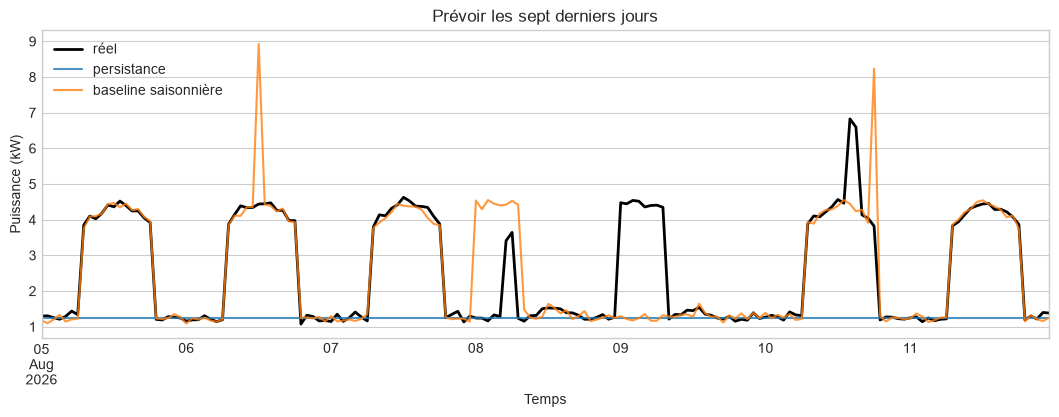

In [6]:
ax = test.plot(figsize=(13, 4), label="réel", color="black", linewidth=2)
persistence.plot(ax=ax, label="persistance", alpha=0.8)
seasonal_naive.plot(ax=ax, label="baseline saisonnière", alpha=0.8)
ax.axvline(test.index.min(), color="grey", linestyle="--", alpha=0.7)
ax.set_ylabel("Puissance (kW)")
ax.set_xlabel("Temps")
ax.set_title("Prévoir les sept derniers jours")
ax.legend()
plt.show()

## Lire la courbe avant de conclure

Le tableau résume 168 erreurs en deux nombres ; le graphique montre **quand** elles arrivent. Vérifiez notamment :

- si les pics sont reproduits ;
- si le modèle se trompe surtout le jour ou la nuit ;
- si une erreur dure plusieurs heures ;
- si une méthode est décalée dans le temps ;
- si quelques instants expliquent une grande RMSE.

Une métrique choisit un gagnant global. L'observation temporelle aide à comprendre ses faiblesses.

### À vous de jouer — calculer la MAE à la main

Recalculez la MAE de la baseline saisonnière uniquement avec les opérations Pandas. Affichez les cinq premières erreurs, puis comparez votre résultat à celui de scikit-learn.

**Contrôles attendus :** les erreurs absolues sont positives, leur index est celui du test et les deux MAE sont identiques à l'arrondi près.

**Indice :** utilisez la différence absolue entre test et seasonal_naive, puis sa moyenne.

In [7]:
# Écrivez votre code ici.
pass

### À vous de jouer — essayer un motif journalier

Répétez les 24 dernières heures d'entraînement sur toute la semaine de test. Calculez sa MAE et sa RMSE, puis comparez-les au motif hebdomadaire.

**Question d'interprétation :** que perd-on en supposant que tous les jours se ressemblent ?

**Indice :** **np.resize** répète un tableau jusqu'à la longueur demandée.

In [8]:
# Écrivez votre code ici.
pass

### À vous de jouer — raisonner sur l'horizon

Sans relancer de modèle, discutez les trois situations suivantes :

1. Prévoir la prochaine heure pour ajuster une consigne HVAC.
2. Prévoir les sept prochains jours pour planifier l'énergie.
3. Prévoir les trois prochains mois pour préparer un budget.

Pour chacune, indiquez si la persistance peut rester crédible, quel motif saisonnier serait utile et pourquoi l'incertitude devrait probablement augmenter avec l'horizon.

In [9]:
# Notez ici votre raisonnement sous forme de commentaires.
pass

## À retenir

- Une prévision s'évalue sur un futur que la méthode n'a pas vu.
- Une baseline est le niveau minimal qu'un modèle plus complexe doit battre.
- La persistance prolonge un niveau ; une baseline saisonnière répète un motif.
- La MAE décrit une erreur absolue moyenne dans l'unité du signal.
- La RMSE donne davantage de poids aux grandes erreurs.
- Une métrique globale doit toujours être complétée par une lecture temporelle.

### Mini-mémo

| Besoin | Réflexe |
|---|---|
| simuler la production | réserver les dernières dates comme test |
| avoir un point de comparaison | construire une baseline avant le modèle |
| lire l'erreur typique | regarder la MAE |
| surveiller les gros échecs | comparer RMSE et MAE |
| comprendre quand le modèle échoue | tracer réel et prévision |